<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Импорт-библиотек-и-загрузка-данных" data-toc-modified-id="Импорт-библиотек-и-загрузка-данных-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Импорт библиотек и загрузка данных</a></span></li><li><span><a href="#Датасет-contract_new" data-toc-modified-id="Датасет-contract_new-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Датасет contract_new</a></span></li><li><span><a href="#Датасет-personal_new" data-toc-modified-id="Датасет-personal_new-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Датасет personal_new</a></span></li><li><span><a href="#Датасет-internet_new" data-toc-modified-id="Датасет-internet_new-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Датасет internet_new</a></span></li><li><span><a href="#Датасет-phone_new" data-toc-modified-id="Датасет-phone_new-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Датасет phone_new</a></span></li><li><span><a href="#План-работы-по-пунктам" data-toc-modified-id="План-работы-по-пунктам-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>План работы по пунктам</a></span></li><li><span><a href="#Вопросы" data-toc-modified-id="Вопросы-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Вопросы</a></span></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Предобработка данных</a></span></li></ul></div>

# Проект "Телекоммуникации"

В данном проекте перед нами стоит задача классификации, целью является построение модели прогноза оттока клиентов для оператора связи «Ниединогоразрыва.ком». Если выяснится, что пользователь планирует уйти, ему будут предложены промокоды и специальные условия. В распоряжении у нас имеются 4 датасета, содержащие информацию о некоторых клиентах, об их тарифах и договорах.

Информация о договорах актуальна на 1 февраля 2020.

Рассмотрим имеющиеся у нас данные.

## Импорт библиотек и загрузка данных

Импортируем необходимые библиотеки и загружаем соответствующие датасеты.

In [1]:
!pip install ydata_profiling

In [2]:
import pandas as pd
import seaborn as sns
import phik
import matplotlib.pyplot as plt
import ydata_profiling
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices
from statsmodels.tools.tools import add_constant 
from sklearn.model_selection import (train_test_split, GridSearchCV)
from sklearn.preprocessing import (OneHotEncoder, StandardScaler)
from catboost import CatBoostClassifier
from catboost import Pool, cv
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

In [3]:
try:
    data = pd.read_csv('D:/Data_Science/datasets/contract_new.csv')
    data2 = pd.read_csv('D:/Data_Science/datasets/personal_new.csv')
    data3 = pd.read_csv('D:/Data_Science/datasets/internet_new.csv')
    data4 = pd.read_csv('D:/Data_Science/datasets/phone_new.csv.csv')
except:
    data = pd.read_csv('datasets/contract_new.csv')
    data2 = pd.read_csv('datasets/personal_new.csv')
    data3 = pd.read_csv('datasets/internet_new.csv')
    data4 = pd.read_csv('datasets/phone_new.csv')

Переходим к рассмотрению датасетов по отдельности.

## Датасет contract_new

Здесь хранятся данные о договорах.

Изначально выведем общую информацию по датасету.

In [4]:
data.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.5


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


Можно отметить отсутствие пропусков.

Можем видеть, что некоторым столбцам (BeginDate и TotalCharges) присвоены неправильные типы данных. Данный момент нужно будет исправить (TotalCharger исправлю ниже).

In [6]:
data['BeginDate'] = pd.to_datetime(data['BeginDate'], format="%Y-%m-%dT%")

Отдельно рассмотрим столбец MonthlyCharges - выведем боксплот и гистограмму распределения.

In [7]:
data['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

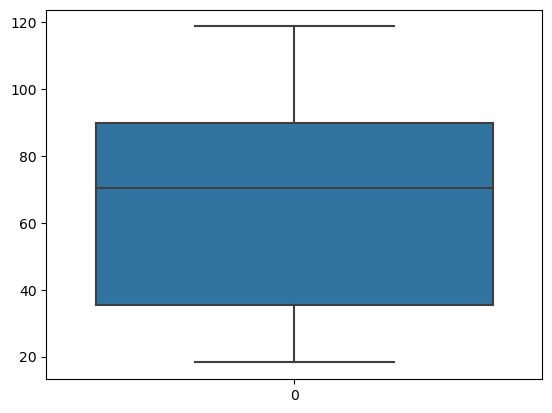

In [8]:
sns.boxplot(data=data['MonthlyCharges']);

По боксплоту отсутствуют аномальные значения.

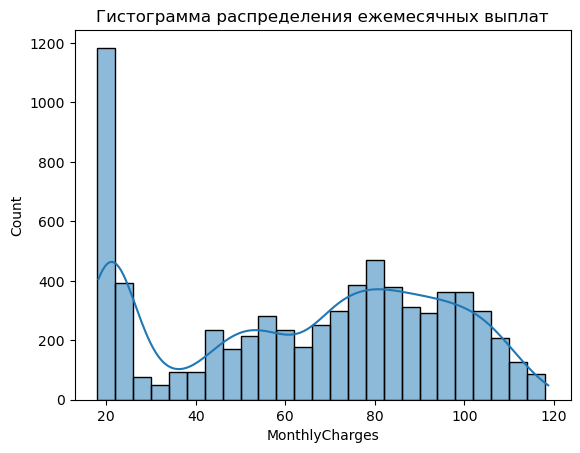

In [9]:
sns.histplot(data=data, bins=25, x='MonthlyCharges', kde=True, binrange=(18, 118)).set_title('Гистограмма распределения ежемесячных выплат');

~В гистограмме распределения можем видеть значительное количество пиковых значений. Возможно это связано с каким-либо рода округлением.~ Можем заметить пик в начале графика, который характеризуется большим количеством одинаковых малых значений (вывел ниже в value_counts), в свою очередь высокие значения более дифференцированы (надеюсь можно так употребить слово), поэтому там отсутствуют такие пиковые значения.

In [10]:
data['MonthlyCharges'].value_counts()

20.05     61
19.85     45
19.95     44
19.90     44
20.00     43
          ..
23.65      1
114.70     1
43.65      1
87.80      1
78.70      1
Name: MonthlyCharges, Length: 1585, dtype: int64

Проведем такой же анализ для TotalCharges, предварительно поменяв тип данных

In [11]:
data = data.loc[data['TotalCharges'] != ' ']

In [12]:
data['TotalCharges'] = data['TotalCharges'].astype(dtype=float)

In [13]:
data['TotalCharges'].describe()

count    7032.000000
mean     2118.621822
std      2112.736199
min        19.050000
25%       439.745000
50%      1345.275000
75%      3239.317500
max      9221.380000
Name: TotalCharges, dtype: float64

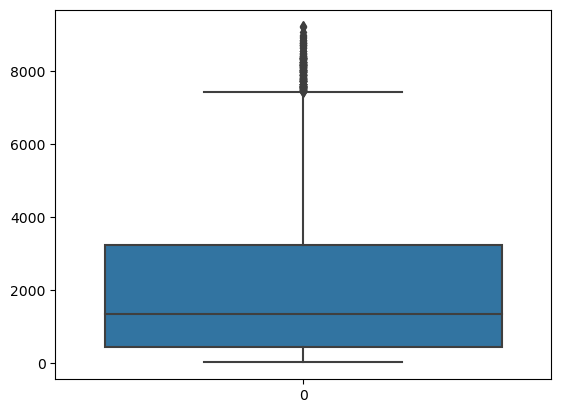

In [14]:
sns.boxplot(data=data['TotalCharges']);

Боксплот показывает аномальные значения. 

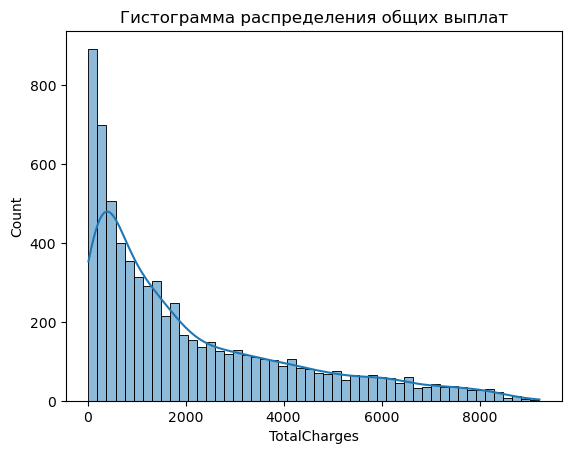

In [15]:
sns.histplot(data=data, bins=50, x='TotalCharges', kde=True).set_title('Гистограмма распределения общих выплат');

Здесь, в отличие от MonthlyCharges, множества пиковых значений нет и распределение характеризуется стабильным понижением количества наблюдений.

Также именно в этом датасете находится таргетное значение - EndDate. Если в этом столбце присутствует дата - значит пользователь ушел.

In [16]:
data['EndDate']

0       No
1       No
2       No
3       No
4       No
        ..
7038    No
7039    No
7040    No
7041    No
7042    No
Name: EndDate, Length: 7032, dtype: object

In [17]:
data['EndDate'].value_counts()

No            5931
2020-01-01      39
2019-12-01      38
2018-11-01      35
2019-09-01      32
              ... 
2014-09-01       2
2014-12-01       2
2014-06-01       1
2014-10-01       1
2014-11-01       1
Name: EndDate, Length: 67, dtype: int64

Заменим значения "No" на нули, а значения с датами на единицы.

In [18]:
#data.loc[(data['EndDate'] != 'No'), 'EndDate'] = 1

In [19]:
#data.loc[(data['EndDate'] == 'No'), 'EndDate']  = 0

In [20]:
data

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.60
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.50
...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,No,One year,Yes,Mailed check,84.80,2035.20
7039,2234-XADUH,2014-02-01,No,One year,Yes,Credit card (automatic),103.20,7430.40
7040,4801-JZAZL,2019-03-01,No,Month-to-month,Yes,Electronic check,29.60,325.60
7041,8361-LTMKD,2019-07-01,No,Month-to-month,Yes,Mailed check,74.40,520.80


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7032 non-null   object        
 1   BeginDate         7032 non-null   datetime64[ns]
 2   EndDate           7032 non-null   object        
 3   Type              7032 non-null   object        
 4   PaperlessBilling  7032 non-null   object        
 5   PaymentMethod     7032 non-null   object        
 6   MonthlyCharges    7032 non-null   float64       
 7   TotalCharges      7032 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 752.5+ KB


In [22]:
data['EndDate'].value_counts(normalize=True)

No            0.843430
2020-01-01    0.005546
2019-12-01    0.005404
2018-11-01    0.004977
2019-09-01    0.004551
                ...   
2014-09-01    0.000284
2014-12-01    0.000284
2014-06-01    0.000142
2014-10-01    0.000142
2014-11-01    0.000142
Name: EndDate, Length: 67, dtype: float64

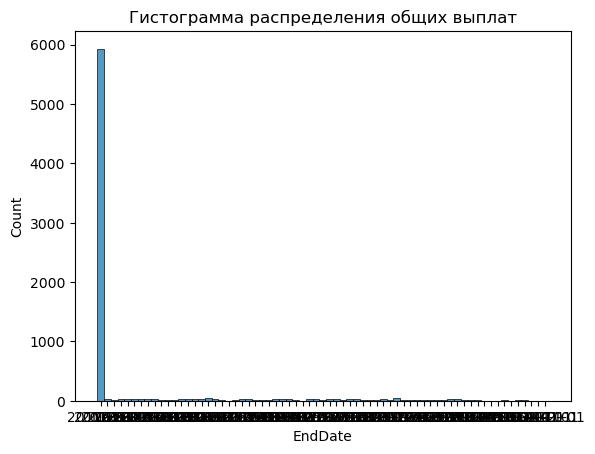

In [23]:
sns.histplot(data=data, bins=75, x='EndDate').set_title('Гистограмма распределения общих выплат');

Таким образом, отток составляет около 16%.

Оставшиеся признаки (тип тарифа, безналичный расчет, метод оплаты) представляют собой строковые значения, которые в дальнейшем, скорее всего, нужно будет преобразовать через One-HotEncoder (Type и PaymentMethod) и OrdinalEncoder (PaperlessBilling).

In [24]:
data[['Type', 'PaperlessBilling', 'PaymentMethod']]

,Type,PaperlessBilling,PaymentMethod
0,Month-to-month,Yes,Electronic check
1,One year,No,Mailed check
2,Month-to-month,Yes,Mailed check
3,One year,No,Bank transfer (automatic)
4,Month-to-month,Yes,Electronic check
...,...,...,...
7038,One year,Yes,Mailed check
7039,One year,Yes,Credit card (automatic)
7040,Month-to-month,Yes,Electronic check
7041,Month-to-month,Yes,Mailed check


In [25]:
data['Type'].value_counts(normalize=True)

Month-to-month    0.551052
Two year          0.239619
One year          0.209329
Name: Type, dtype: float64

In [26]:
data['PaperlessBilling'].value_counts(normalize=True)

Yes    0.592719
No     0.407281
Name: PaperlessBilling, dtype: float64

In [27]:
data['PaymentMethod'].value_counts(normalize=True)

Electronic check             0.336320
Mailed check                 0.228100
Bank transfer (automatic)    0.219283
Credit card (automatic)      0.216297
Name: PaymentMethod, dtype: float64

## Датасет personal_new

Здесь содержится информация о данных клиента.

In [28]:
data2.head()

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [29]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


Признак SeniorCitizen подразумевает нахождение гражданина в категории пенсионеров, рассмотрим его соотношение

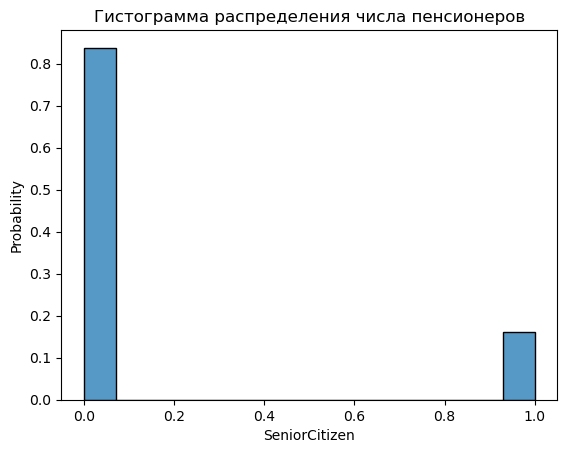

In [30]:
sns.histplot(data=data2, x='SeniorCitizen', stat='probability').set_title('Гистограмма распределения числа пенсионеров');

In [31]:
data2['SeniorCitizen'].value_counts(normalize=True)

0    0.837853
1    0.162147
Name: SeniorCitizen, dtype: float64

Около 16% клиентов - пенсионеры.

По такому же принципу можно взглянуть на другие признаки

In [32]:
data2['gender'].value_counts(normalize=True)

Male      0.504756
Female    0.495244
Name: gender, dtype: float64

In [33]:
data2['Partner'].value_counts(normalize=True)

No     0.516967
Yes    0.483033
Name: Partner, dtype: float64

In [34]:
data2['Dependents'].value_counts(normalize=True)

No     0.700412
Yes    0.299588
Name: Dependents, dtype: float64

Признаки gender, Partner и Dependents будем преобразовывать через порядкое кодирование. В отношении SeniorCitizen ничего делать не нужно.

## Датасет internet_new

Здесь содержится информация об интернет-услугах клиентов.

In [35]:
data3.head()

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [36]:
data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


Отсутствуют какие-либо числовые значения. Тем не менее, можно взглянуть на соотношения строковый значений.

In [37]:
data3['InternetService'].value_counts(normalize=True)

Fiber optic    0.561175
DSL            0.438825
Name: InternetService, dtype: float64

In [38]:
data3['OnlineSecurity'].value_counts(normalize=True)

No     0.63404
Yes    0.36596
Name: OnlineSecurity, dtype: float64

In [39]:
data3['OnlineBackup'].value_counts(normalize=True)

No     0.559724
Yes    0.440276
Name: OnlineBackup, dtype: float64

In [40]:
data3['DeviceProtection'].value_counts(normalize=True)

No     0.560993
Yes    0.439007
Name: DeviceProtection, dtype: float64

In [41]:
data3['TechSupport'].value_counts(normalize=True)

No     0.629509
Yes    0.370491
Name: TechSupport, dtype: float64

In [42]:
data3['StreamingTV'].value_counts(normalize=True)

No     0.509335
Yes    0.490665
Name: StreamingTV, dtype: float64

In [43]:
data3['StreamingMovies'].value_counts(normalize=True)

No     0.504803
Yes    0.495197
Name: StreamingMovies, dtype: float64

В большинстве случаев мы имеем дело с двумя относительно сбалансированными классами, в этих случаях подойдет применение именно порядкого кодирования.

## Датасет phone_new

Информация об услугах телефонии.

In [44]:
data4.head()

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [45]:
data4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


In [46]:
data4['MultipleLines'].value_counts(normalize=True)

No     0.532935
Yes    0.467065
Name: MultipleLines, dtype: float64

Столбец содержит в себе лишь один признак со сбалансированным соотношением, характеризующий возможность ведения параллельных линий во время звонка. Опять же, применим в отношении него порядкое кодирование.

## План работы по пунктам

Таким образом мы в общем и целом проанализировали имеющиеся у нас данные.

Теперь стоит задача исполнения следующего плана:

 
1. Объединение всех датасетов в одну таблицу по признаку customerID комбинированием методов inner и outer (чтобы не потерять большое количество данных) - датасет personal_new объединим методом inner, а датасеты phone_new и internet_new - outer (чтобы учитывать отличие пользователей интернет-услуг от пользователей телефонных услуг);
2. Проведение предобработки данных - поиск аномальных значений, поиск дубликатов, приведение признаков к единому стилю, изменение типов данных;
3. Создание нового признака - длительность жизни клиента (лучше всего в днях);
4. Удаление признака customerID, а также удаление мультиколлинеарных (phik) и прочих ненужных признаков;
5. Определение признаков и таргета, а также формирование тренировочной и тестовой выборок в соотношении 75:25 (вместо валидационной выборки будем использовать кросс-валидацию);
6. Кодировка текстовых признаков методами порядкого (PaperlessBilling, gender, Partner, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, MultipleLines) и прямого (Type, PaymentMethod) кодирования (для моделей градиентного бустинга не будем проводить кодировку);
7. Мастштабирование числовых признаков.
8. Проведение обучения моделей градиентного бустинга (CatBoost и LGBM) и случайного леса с применением пайплайна. Использование random_state=30723 и сбалансирования классов соответствующим гиперпараметром. Подбор наилучших гиперпараметров с использованием GridSearch. Использовать будем метрику ROC-AUC и дополнительные метрики (precision, recall, F1);
9. Выбор модели с наибольшим показателем метрики качества. Проверка на тестововой выборке. Вывод ROC-AUC, а также матрицы ошибок и дополнительных метрик (precision, recall, F1). Исследование наилучшей модели - вывод важности признаков (Shap, Feature importance);
10. Написание отчета

Это общий набросок плана, отдельные моменты могут меняться.

Объединять признаки будем методом ниже.

In [47]:
data = data.merge(data2, how='inner', on='customerID')
data = data.merge(data3,  how='outer', on='customerID')
data = data.merge(data4, how='outer', on='customerID')
data

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04,Female,0.0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84,Male,0.0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17,Male,0.0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.60,Male,0.0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.50,Female,0.0,No,No,Fiber optic,No,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,4367-NUYAO,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes
7039,7644-OMVMY,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
7040,3213-VVOLG,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes
7041,2520-SGTTA,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No


## Предобработка данных

In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7032 non-null   datetime64[ns]
 2   EndDate           7032 non-null   object        
 3   Type              7032 non-null   object        
 4   PaperlessBilling  7032 non-null   object        
 5   PaymentMethod     7032 non-null   object        
 6   MonthlyCharges    7032 non-null   float64       
 7   TotalCharges      7032 non-null   float64       
 8   gender            7032 non-null   object        
 9   SeniorCitizen     7032 non-null   float64       
 10  Partner           7032 non-null   object        
 11  Dependents        7032 non-null   object        
 12  InternetService   5517 non-null   object        
 13  OnlineSecurity    5517 non-null   object        
 14  OnlineBackup      5517 n

In [49]:
data

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04,Female,0.0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84,Male,0.0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17,Male,0.0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.60,Male,0.0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.50,Female,0.0,No,No,Fiber optic,No,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,4367-NUYAO,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes
7039,7644-OMVMY,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
7040,3213-VVOLG,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes
7041,2520-SGTTA,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No


In [50]:
data['EndDate'].value_counts()

No            5931
2020-01-01      39
2019-12-01      38
2018-11-01      35
2019-09-01      32
              ... 
2014-09-01       2
2014-12-01       2
2014-06-01       1
2014-10-01       1
2014-11-01       1
Name: EndDate, Length: 67, dtype: int64

In [51]:
data.isna().sum()

customerID             0
BeginDate             11
EndDate               11
Type                  11
PaperlessBilling      11
PaymentMethod         11
MonthlyCharges        11
TotalCharges          11
gender                11
SeniorCitizen         11
Partner               11
Dependents            11
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
MultipleLines        682
dtype: int64

In [52]:
#data['InternetService'].fillna('no_internet', inplace=True)

In [53]:
data['MultipleLines'].fillna('no_telephone', inplace=True)

In [54]:
cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

In [55]:
for col in cols:
    data[col].fillna('no_internet', inplace=True)

In [56]:
#data[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']].fillna('No', inplace=True)

In [57]:
#cols2 = ['BeginDate', 'EndDate', 'Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'gender', 'SeniorCitizen', 'Partner', 'Dependents']

In [58]:
#for col in cols2:
    #data[col].dropna(inplace=True)

In [59]:
data.dropna(inplace=True)

In [60]:
#data[['BeginDate', 'EndDate', 'Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'gender', 'SeniorCitizen', 'Partner', 'Dependents']].dropna(inplace=True)

In [61]:
data.isna().sum()

customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
dtype: int64

In [62]:
#data['EndDate'] = data['EndDate'].astype(dtype='int')
data['SeniorCitizen'] = data['SeniorCitizen'].astype(dtype='int')
data.rename(columns = {'customerID': 'customer_id', 'BeginDate': 'begin_date', \
                       'EndDate': 'end_date', 'Type': 'type', 'PaperlessBilling': 'paperless_billing', \
                       'PaymentMethod': 'payment_method', 'MonthlyCharges': 'monthly_charges', \
                       'TotalCharges': 'total_charges', 'SeniorCitizen': 'senior_citizen', \
                       'Partner': 'partner', 'Dependents': 'dependents', 'InternetSerivice': 'internet_service', \
                       'OnlineSecurity': 'online_security', 'OnlineBackup': 'online_backup', \
                       'DeviceProtection': 'device_protection', 'TechSupport': 'tech_support', \
                       'StreamingTV': 'streaming_tv', 'StreamingMovies': 'streaming_movies', \
                       'MultipleLines': 'multiple_lines'}, inplace=True)

Не знаешь, есть ли какой нибудь инструмент, который самостоятельно бы приводил названия признаков к нужному формату?

In [63]:
data

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,InternetService,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,no_telephone
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.60,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,no_telephone
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.50,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,2018-02-01,No,One year,Yes,Mailed check,84.80,2035.20,Male,0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes
7028,2234-XADUH,2014-02-01,No,One year,Yes,Credit card (automatic),103.20,7430.40,Female,0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes
7029,4801-JZAZL,2019-03-01,No,Month-to-month,Yes,Electronic check,29.60,325.60,Female,0,Yes,Yes,DSL,Yes,No,No,No,No,No,no_telephone
7030,8361-LTMKD,2019-07-01,No,Month-to-month,Yes,Mailed check,74.40,520.80,Male,1,Yes,No,Fiber optic,No,No,No,No,No,No,Yes


In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7032 non-null   object        
 1   begin_date         7032 non-null   datetime64[ns]
 2   end_date           7032 non-null   object        
 3   type               7032 non-null   object        
 4   paperless_billing  7032 non-null   object        
 5   payment_method     7032 non-null   object        
 6   monthly_charges    7032 non-null   float64       
 7   total_charges      7032 non-null   float64       
 8   gender             7032 non-null   object        
 9   senior_citizen     7032 non-null   int32         
 10  partner            7032 non-null   object        
 11  dependents         7032 non-null   object        
 12  InternetService    7032 non-null   object        
 13  online_security    7032 non-null   object        
 14  online_b

In [65]:
data.loc[(data['end_date'] == 'No'), 'end_date'] = '2020-02-01'

In [66]:
data.head(50)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,InternetService,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,2020-01-01,2020-02-01,Month-to-month,Yes,Electronic check,29.85,31.04,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,no_telephone
1,5575-GNVDE,2017-04-01,2020-02-01,One year,No,Mailed check,56.95,2071.84,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2020-02-01,Month-to-month,Yes,Mailed check,53.85,226.17,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,2020-02-01,One year,No,Bank transfer (automatic),42.30,1960.60,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,no_telephone
4,9237-HQITU,2019-09-01,2020-02-01,Month-to-month,Yes,Electronic check,70.70,353.50,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No
5,9305-CDSKC,2019-03-01,2020-02-01,Month-to-month,Yes,Electronic check,99.65,1150.96,Female,0,No,No,Fiber optic,No,No,Yes,No,Yes,Yes,Yes
6,1452-KIOVK,2018-04-01,2020-02-01,Month-to-month,Yes,Credit card (automatic),89.10,2058.21,Male,0,No,Yes,Fiber optic,No,Yes,No,No,Yes,No,Yes
7,6713-OKOMC,2019-04-01,2020-02-01,Month-to-month,No,Mailed check,29.75,300.48,Female,0,No,No,DSL,Yes,No,No,No,No,No,no_telephone
8,7892-POOKP,2017-07-01,2020-02-01,Month-to-month,Yes,Electronic check,104.80,3573.68,Female,0,Yes,No,Fiber optic,No,No,Yes,Yes,Yes,Yes,Yes
9,6388-TABGU,2014-12-01,2017-05-01,One year,No,Bank transfer (automatic),56.15,1628.35,Male,0,No,Yes,DSL,Yes,Yes,No,No,No,No,No


In [67]:
data['life_cycle'] = (pd.to_datetime(data['end_date']) - pd.to_datetime(data['begin_date'])).dt.days

In [68]:
data

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,...,dependents,InternetService,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,life_cycle
0,7590-VHVEG,2020-01-01,2020-02-01,Month-to-month,Yes,Electronic check,29.85,31.04,Female,0,...,No,DSL,No,Yes,No,No,No,No,no_telephone,31
1,5575-GNVDE,2017-04-01,2020-02-01,One year,No,Mailed check,56.95,2071.84,Male,0,...,No,DSL,Yes,No,Yes,No,No,No,No,1036
2,3668-QPYBK,2019-10-01,2020-02-01,Month-to-month,Yes,Mailed check,53.85,226.17,Male,0,...,No,DSL,Yes,Yes,No,No,No,No,No,123
3,7795-CFOCW,2016-05-01,2020-02-01,One year,No,Bank transfer (automatic),42.30,1960.60,Male,0,...,No,DSL,Yes,No,Yes,Yes,No,No,no_telephone,1371
4,9237-HQITU,2019-09-01,2020-02-01,Month-to-month,Yes,Electronic check,70.70,353.50,Female,0,...,No,Fiber optic,No,No,No,No,No,No,No,153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,2018-02-01,2020-02-01,One year,Yes,Mailed check,84.80,2035.20,Male,0,...,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes,730
7028,2234-XADUH,2014-02-01,2020-02-01,One year,Yes,Credit card (automatic),103.20,7430.40,Female,0,...,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,2191
7029,4801-JZAZL,2019-03-01,2020-02-01,Month-to-month,Yes,Electronic check,29.60,325.60,Female,0,...,Yes,DSL,Yes,No,No,No,No,No,no_telephone,337
7030,8361-LTMKD,2019-07-01,2020-02-01,Month-to-month,Yes,Mailed check,74.40,520.80,Male,1,...,No,Fiber optic,No,No,No,No,No,No,Yes,215


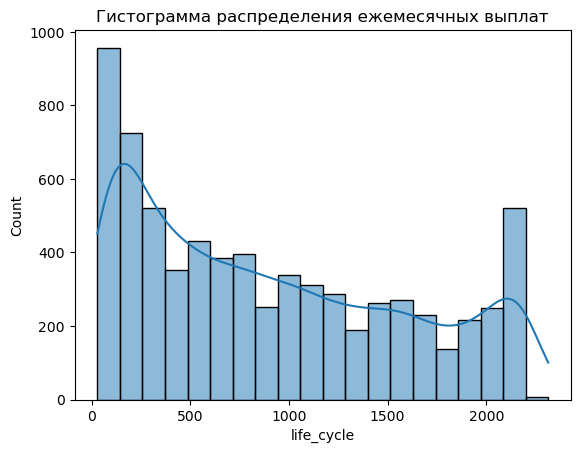

In [69]:
sns.histplot(data=data, bins=20, x='life_cycle', kde=True).set_title('Гистограмма распределения ежемесячных выплат');

In [70]:
data['life_cycle'].describe()

count    7032.000000
mean      899.961320
std       682.738777
min        28.000000
25%       276.000000
50%       761.000000
75%      1461.000000
max      2314.000000
Name: life_cycle, dtype: float64

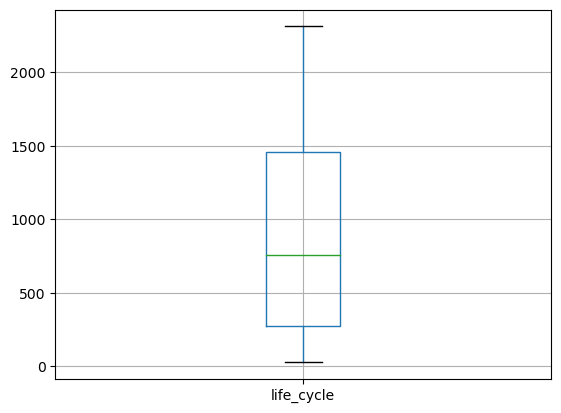

In [71]:
data.boxplot('life_cycle');

In [72]:
data.duplicated().sum()

0

In [73]:
data.drop(['customer_id', 'begin_date'], axis=1, inplace=True)

In [74]:
data.loc[(data['end_date'] != '2020-02-01'), 'end_date'] = 1
data.loc[(data['end_date'] == '2020-02-01'), 'end_date']  = 0

In [75]:
data

,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,InternetService,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,life_cycle
0,0,Month-to-month,Yes,Electronic check,29.85,31.04,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,no_telephone,31
1,0,One year,No,Mailed check,56.95,2071.84,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No,1036
2,0,Month-to-month,Yes,Mailed check,53.85,226.17,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No,123
3,0,One year,No,Bank transfer (automatic),42.30,1960.60,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,no_telephone,1371
4,0,Month-to-month,Yes,Electronic check,70.70,353.50,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No,153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,One year,Yes,Mailed check,84.80,2035.20,Male,0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes,730
7028,0,One year,Yes,Credit card (automatic),103.20,7430.40,Female,0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,2191
7029,0,Month-to-month,Yes,Electronic check,29.60,325.60,Female,0,Yes,Yes,DSL,Yes,No,No,No,No,No,no_telephone,337
7030,0,Month-to-month,Yes,Mailed check,74.40,520.80,Male,1,Yes,No,Fiber optic,No,No,No,No,No,No,Yes,215


In [76]:
phik = data.phik_matrix()

interval columns not set, guessing: ['monthly_charges', 'total_charges', 'senior_citizen', 'life_cycle']


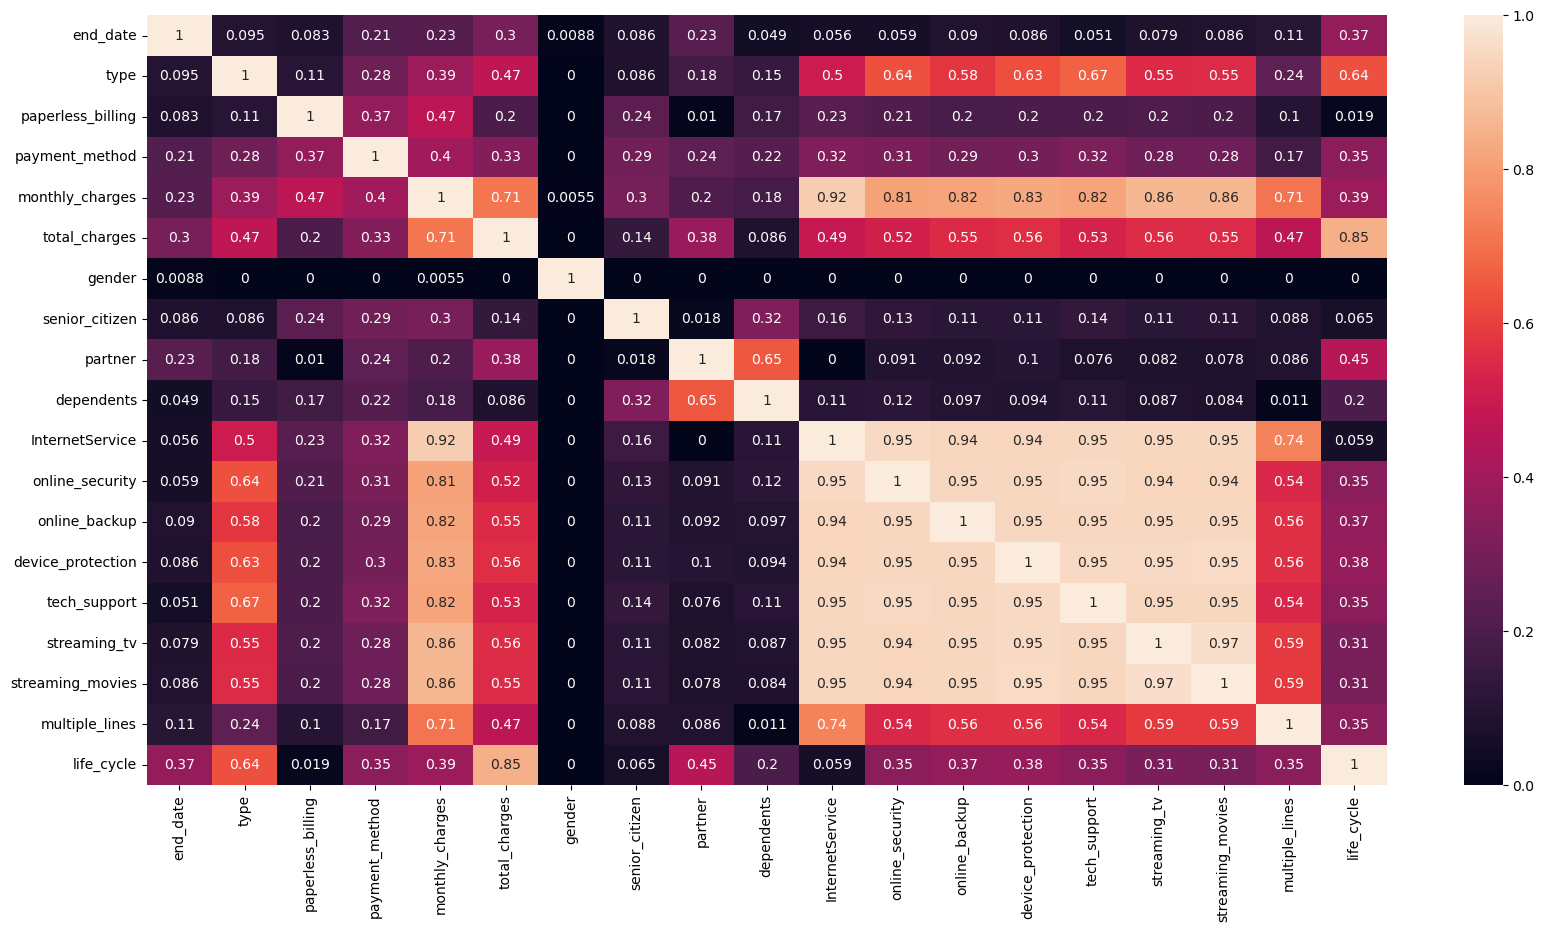

In [77]:
fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(phik, annot=True);

In [78]:
#y, X = dmatrices('InternetService ~ tech_support', data=data, return_type='dataframe')

In [79]:
# vif = pd.DataFrame()
# vif['VIF'] = [variance_inflation_factor(data['total_charges'].values, i) for i in range(data['total_charges'].shape[1])]
# vif['variable'] = data['total_charges'].columns

In [80]:
X = add_constant(data[['monthly_charges', 'total_charges', 'life_cycle']])  
ds=pd.Series([variance_inflation_factor(X.values, i)   
               for i in range(X.shape[1])],   
              index=X.columns) 
ds

const              14.655078
monthly_charges     3.046779
total_charges       8.918872
life_cycle          5.646328
dtype: float64

In [81]:
data.drop(['streaming_movies', 'tech_support', 'online_backup'], axis=1, inplace=True)

interval columns not set, guessing: ['monthly_charges', 'total_charges', 'senior_citizen', 'life_cycle']


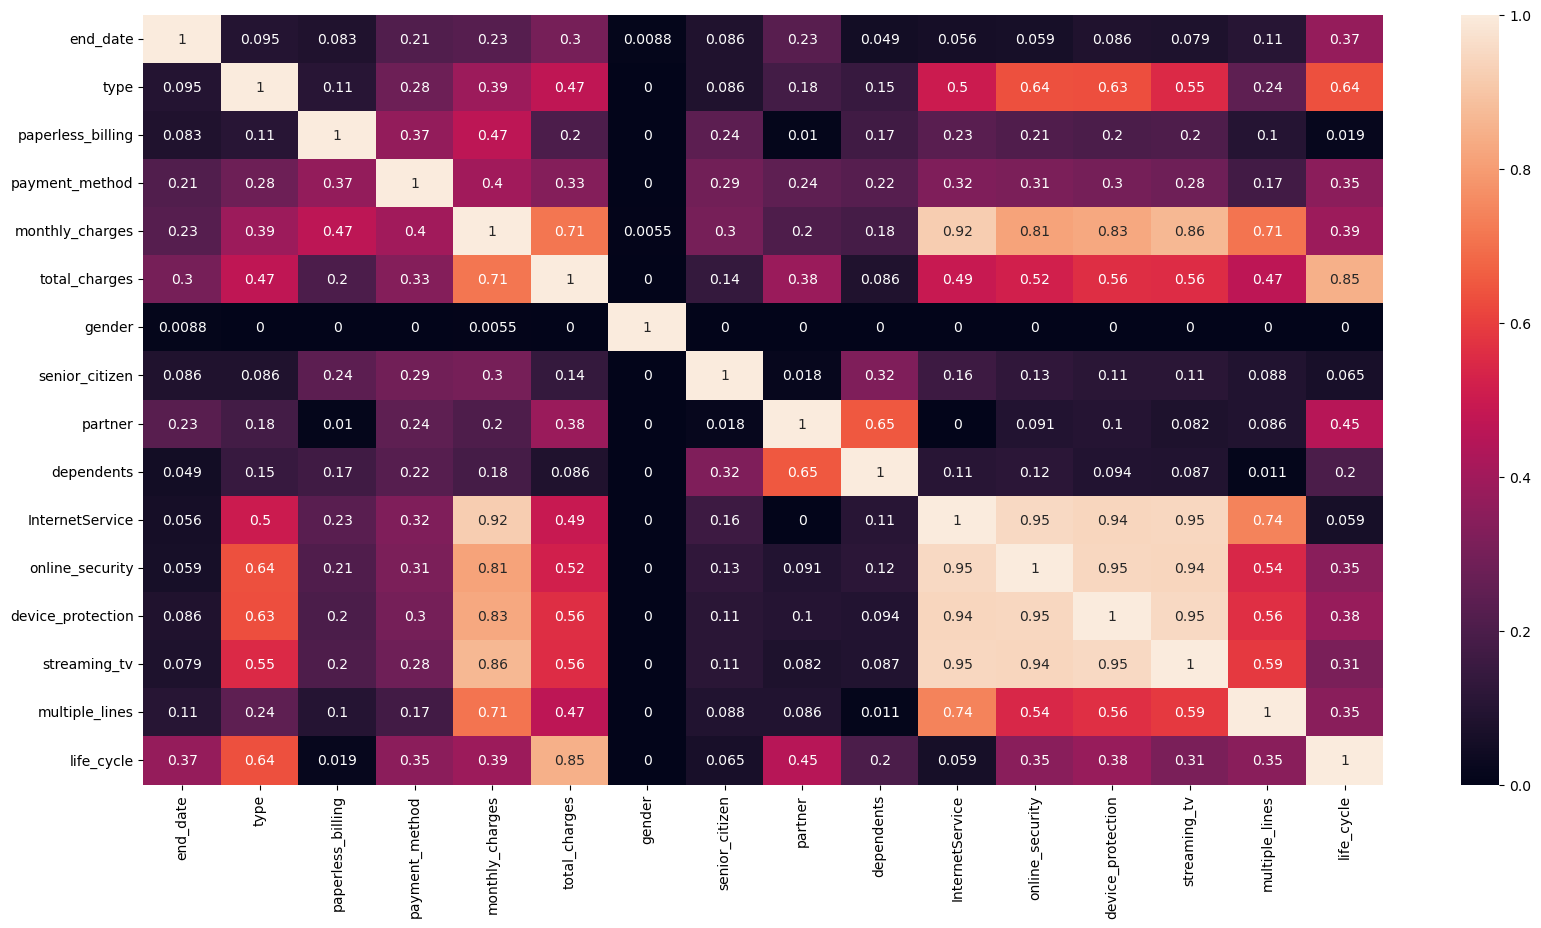

In [82]:
phik = data.phik_matrix()
fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(phik, annot=True);

In [83]:
data

,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,InternetService,online_security,device_protection,streaming_tv,multiple_lines,life_cycle
0,0,Month-to-month,Yes,Electronic check,29.85,31.04,Female,0,Yes,No,DSL,No,No,No,no_telephone,31
1,0,One year,No,Mailed check,56.95,2071.84,Male,0,No,No,DSL,Yes,Yes,No,No,1036
2,0,Month-to-month,Yes,Mailed check,53.85,226.17,Male,0,No,No,DSL,Yes,No,No,No,123
3,0,One year,No,Bank transfer (automatic),42.30,1960.60,Male,0,No,No,DSL,Yes,Yes,No,no_telephone,1371
4,0,Month-to-month,Yes,Electronic check,70.70,353.50,Female,0,No,No,Fiber optic,No,No,No,No,153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,One year,Yes,Mailed check,84.80,2035.20,Male,0,Yes,Yes,DSL,Yes,Yes,Yes,Yes,730
7028,0,One year,Yes,Credit card (automatic),103.20,7430.40,Female,0,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,2191
7029,0,Month-to-month,Yes,Electronic check,29.60,325.60,Female,0,Yes,Yes,DSL,Yes,No,No,no_telephone,337
7030,0,Month-to-month,Yes,Mailed check,74.40,520.80,Male,1,Yes,No,Fiber optic,No,No,No,Yes,215


In [84]:
#ydata_profiling.ProfileReport(data)

In [85]:
data['end_date'].value_counts(normalize=True)

0    0.84343
1    0.15657
Name: end_date, dtype: float64

In [86]:
features = data.drop(['end_date'], axis=1)
target = data['end_date'] 

features_train, features_test, target_train, target_test = train_test_split(
     features, target, test_size=0.25, random_state=12345) #, stratify=target

In [87]:
print(features_train.shape)
print(target_train.shape)

print(features_test.shape)
print(target_test.shape)

(5274, 15)
(5274,)
(1758, 15)
(1758,)


In [88]:
features_train_for_cat = features_train.copy()
features_test_for_cat = features_test.copy()

In [89]:
ohe_features_ridge = features_train.select_dtypes(include='object').columns.to_list()
#ohe_features_ridge.remove('Brand')
#ohe_features_ridge.remove('Model')
ohe_features_ridge

['type',
 'paperless_billing',
 'payment_method',
 'gender',
 'partner',
 'dependents',
 'InternetService',
 'online_security',
 'device_protection',
 'streaming_tv',
 'multiple_lines']

In [90]:
features_train_ridge = features_train.copy()
features_test_ridge = features_test.copy()

In [91]:
encoder_ohe = OneHotEncoder(drop='first', sparse=False)
encoder_ohe.fit(features_train_ridge[ohe_features_ridge])

OneHotEncoder(drop='first', sparse=False)

In [92]:
features_train[
    encoder_ohe.get_feature_names()
] = encoder_ohe.transform(features_train_ridge[ohe_features_ridge])

features_train = features_train.drop(ohe_features_ridge, axis=1)

features_train

,monthly_charges,total_charges,senior_citizen,life_cycle,x0_One year,x0_Two year,x1_Yes,x2_Credit card (automatic),x2_Electronic check,x2_Mailed check,...,x6_Fiber optic,x6_no_internet,x7_Yes,x7_no_internet,x8_Yes,x8_no_internet,x9_Yes,x9_no_internet,x10_Yes,x10_no_telephone
5486,73.85,1106.27,0,427,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2004,79.25,5547.50,0,2132,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1795,43.85,43.85,0,31,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5621,103.45,1506.23,0,426,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
6286,20.20,979.30,0,1461,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3497,104.25,7430.94,0,2010,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3492,75.20,3534.40,0,1432,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2177,103.20,5894.78,0,1706,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3557,90.50,2986.50,1,914,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [93]:
features_test[
    encoder_ohe.get_feature_names()
] = encoder_ohe.transform(features_test_ridge[ohe_features_ridge])

features_test = features_test.drop(ohe_features_ridge, axis=1)

features_test

,monthly_charges,total_charges,senior_citizen,life_cycle,x0_One year,x0_Two year,x1_Yes,x2_Credit card (automatic),x2_Electronic check,x2_Mailed check,...,x6_Fiber optic,x6_no_internet,x7_Yes,x7_no_internet,x8_Yes,x8_no_internet,x9_Yes,x9_no_internet,x10_Yes,x10_no_telephone
3276,94.80,5109.72,0,1492,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1620,75.75,999.90,0,365,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4598,25.00,275.00,0,337,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
5434,45.45,1181.70,0,792,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2757,99.30,2482.50,0,761,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
658,20.35,752.95,0,1126,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3605,99.65,4249.08,0,1248,0.0,1.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4863,75.20,3985.60,0,1614,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3119,82.85,5690.14,0,2071,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [94]:
numeric = ['monthly_charges', 'total_charges', 'life_cycle']

scaler = StandardScaler()
features_train[numeric] = scaler.fit_transform(features_train[numeric])
features_test[numeric] = scaler.transform(features_test[numeric])
pd.options.mode.chained_assignment = None

In [95]:
features_train.head()

,monthly_charges,total_charges,senior_citizen,life_cycle,x0_One year,x0_Two year,x1_Yes,x2_Credit card (automatic),x2_Electronic check,x2_Mailed check,...,x6_Fiber optic,x6_no_internet,x7_Yes,x7_no_internet,x8_Yes,x8_no_internet,x9_Yes,x9_no_internet,x10_Yes,x10_no_telephone
5486,0.296184,-0.486257,0,-0.699242,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2004,0.475876,1.604051,0,1.790992,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1795,-0.702104,-0.986296,0,-1.277619,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5621,1.281161,-0.298012,0,-0.700703,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
6286,-1.489087,-0.546017,0,0.810964,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [96]:
features_test.head()

,monthly_charges,total_charges,senior_citizen,life_cycle,x0_One year,x0_Two year,x1_Yes,x2_Credit card (automatic),x2_Electronic check,x2_Mailed check,...,x6_Fiber optic,x6_no_internet,x7_Yes,x7_no_internet,x8_Yes,x8_no_internet,x9_Yes,x9_no_internet,x10_Yes,x10_no_telephone
3276,0.993321,1.398005,0,0.856241,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1620,0.359409,-0.536321,0,-0.789796,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4598,-1.329361,-0.877503,0,-0.830691,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
5434,-0.648862,-0.450755,0,-0.166142,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2757,1.143064,0.161479,0,-0.211419,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [97]:
features_train_for_cat.head()

,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,InternetService,online_security,device_protection,streaming_tv,multiple_lines,life_cycle
5486,Month-to-month,Yes,Electronic check,73.85,1106.27,Male,0,No,No,Fiber optic,No,No,No,No,427
2004,Two year,Yes,Bank transfer (automatic),79.25,5547.50,Male,0,Yes,Yes,DSL,Yes,Yes,Yes,Yes,2132
1795,Month-to-month,Yes,Bank transfer (automatic),43.85,43.85,Male,0,No,No,DSL,No,No,No,No,31
5621,Month-to-month,Yes,Electronic check,103.45,1506.23,Female,0,No,No,Fiber optic,No,Yes,Yes,Yes,426
6286,Two year,No,Bank transfer (automatic),20.20,979.30,Female,0,Yes,Yes,no_internet,no_internet,no_internet,no_internet,No,1461


In [98]:
features_test_for_cat.head()

,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,InternetService,online_security,device_protection,streaming_tv,multiple_lines,life_cycle
3276,Two year,Yes,Electronic check,94.80,5109.72,Male,0,Yes,No,Fiber optic,No,No,Yes,No,1492
1620,Month-to-month,Yes,Bank transfer (automatic),75.75,999.90,Female,0,Yes,No,Fiber optic,No,Yes,No,No,365
4598,Two year,No,Mailed check,25.00,275.00,Female,0,Yes,Yes,no_internet,no_internet,no_internet,no_internet,Yes,337
5434,Month-to-month,No,Electronic check,45.45,1181.70,Male,0,No,No,DSL,No,No,No,No,792
2757,Two year,No,Bank transfer (automatic),99.30,2482.50,Male,0,No,No,Fiber optic,No,Yes,Yes,No,761


In [99]:
cat_feats = list(features_train_for_cat.select_dtypes(include='object').columns)
cat_feats

['type',
 'paperless_billing',
 'payment_method',
 'gender',
 'partner',
 'dependents',
 'InternetService',
 'online_security',
 'device_protection',
 'streaming_tv',
 'multiple_lines']

In [100]:
cat = CatBoostClassifier(custom_metric=['AUC'], eval_metric='AUC:hints=skip_train~false', random_state=30723, auto_class_weights='SqrtBalanced')

In [101]:
#pipeline_cat = Pipeline([
#    ('model', CatBoostClassifier(loss_function='AUC', random_state=30723, auto_class_weights='SqrtBalanced'))])

In [102]:
train_dataset = Pool(features_train_for_cat, target_train, cat_features=cat_feats) 

eval_dataset = Pool(features_test_for_cat, target_test, cat_features=cat_feats)

In [103]:
parameters_cat = {
        'iterations': [100, 150, 200],
        'learning_rate': [0.15, 0.2],
        'depth': [8, 10]
        
}

In [104]:
gs_cat = cat.grid_search(parameters_cat, train_dataset, plot=True) # features_train, target_train,

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.7799126	test: 0.7387624	best: 0.7387624 (0)	total: 216ms	remaining: 21.4s
1:	learn: 0.7958495	test: 0.7422726	best: 0.7422726 (1)	total: 272ms	remaining: 13.3s
2:	learn: 0.8023455	test: 0.7489171	best: 0.7489171 (2)	total: 325ms	remaining: 10.5s
3:	learn: 0.8009806	test: 0.7493370	best: 0.7493370 (3)	total: 338ms	remaining: 8.11s
4:	learn: 0.8113295	test: 0.7482431	best: 0.7493370 (3)	total: 391ms	remaining: 7.43s
5:	learn: 0.8129288	test: 0.7484309	best: 0.7493370 (3)	total: 453ms	remaining: 7.09s
6:	learn: 0.8263101	test: 0.7668398	best: 0.7668398 (6)	total: 504ms	remaining: 6.69s
7:	learn: 0.8340482	test: 0.7806372	best: 0.7806372 (7)	total: 554ms	remaining: 6.37s
8:	learn: 0.8351325	test: 0.7860331	best: 0.7860331 (8)	total: 575ms	remaining: 5.82s
9:	learn: 0.8418288	test: 0.7946740	best: 0.7946740 (9)	total: 626ms	remaining: 5.63s
10:	learn: 0.8442835	test: 0.7983168	best: 0.7983168 (10)	total: 669ms	remaining: 5.42s
11:	learn: 0.8512294	test: 0.8007772	best: 0.8007772

97:	learn: 0.9704612	test: 0.8419006	best: 0.8419006 (97)	total: 4.54s	remaining: 92.7ms
98:	learn: 0.9719066	test: 0.8416206	best: 0.8419006 (97)	total: 4.61s	remaining: 46.6ms
99:	learn: 0.9730326	test: 0.8421731	best: 0.8421731 (99)	total: 4.67s	remaining: 0us

bestTest = 0.8421731123
bestIteration = 99

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
0:	loss: 0.8421731	best: 0.8421731 (0)	total: 4.92s	remaining: 54.1s
0:	learn: 0.7799126	test: 0.7387624	best: 0.7387624 (0)	total: 49.3ms	remaining: 4.88s
1:	learn: 0.7986433	test: 0.7411676	best: 0.7411676 (1)	total: 99.6ms	remaining: 4.88s
2:	learn: 0.8054229	test: 0.7480442	best: 0.7480442 (2)	total: 158ms	remaining: 5.1s
3:	learn: 0.8323966	test: 0.7749245	best: 0.7749245 (3)	total: 210ms	remaining: 5.05s
4:	learn: 0.8414504	test: 0.7901805	best: 0.7901805 (4)	total: 272ms	remaining: 5.17s
5:	learn: 0.8524336	test: 0.8008877	best: 0.8008877 (5)	t

91:	learn: 0.9880195	test: 0.8248177	best: 0.8298858 (81)	total: 5.01s	remaining: 436ms
92:	learn: 0.9885562	test: 0.8266225	best: 0.8298858 (81)	total: 5.07s	remaining: 382ms
93:	learn: 0.9890341	test: 0.8273444	best: 0.8298858 (81)	total: 5.12s	remaining: 327ms
94:	learn: 0.9895174	test: 0.8262247	best: 0.8298858 (81)	total: 5.18s	remaining: 272ms
95:	learn: 0.9897222	test: 0.8260773	best: 0.8298858 (81)	total: 5.25s	remaining: 219ms
96:	learn: 0.9900216	test: 0.8300773	best: 0.8300773 (96)	total: 5.32s	remaining: 164ms
97:	learn: 0.9905166	test: 0.8331492	best: 0.8331492 (97)	total: 5.38s	remaining: 110ms
98:	learn: 0.9909032	test: 0.8327956	best: 0.8331492 (97)	total: 5.45s	remaining: 55.1ms
99:	learn: 0.9910721	test: 0.8330829	best: 0.8331492 (97)	total: 5.52s	remaining: 0us

bestTest = 0.8331491713
bestIteration = 97

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
1:	loss: 0.8331492	best: 0.842

82:	learn: 0.9545603	test: 0.8290608	best: 0.8304088 (81)	total: 3.75s	remaining: 3.03s
83:	learn: 0.9553447	test: 0.8300184	best: 0.8304088 (81)	total: 3.8s	remaining: 2.99s
84:	learn: 0.9567413	test: 0.8335322	best: 0.8335322 (84)	total: 3.85s	remaining: 2.94s
85:	learn: 0.9583179	test: 0.8327661	best: 0.8335322 (84)	total: 3.9s	remaining: 2.9s
86:	learn: 0.9596945	test: 0.8337090	best: 0.8337090 (86)	total: 3.95s	remaining: 2.86s
87:	learn: 0.9602049	test: 0.8339448	best: 0.8339448 (87)	total: 4.01s	remaining: 2.82s
88:	learn: 0.9607912	test: 0.8344383	best: 0.8344383 (88)	total: 4.07s	remaining: 2.79s
89:	learn: 0.9617066	test: 0.8356685	best: 0.8356685 (89)	total: 4.13s	remaining: 2.75s
90:	learn: 0.9634268	test: 0.8372818	best: 0.8372818 (90)	total: 4.19s	remaining: 2.72s
91:	learn: 0.9646833	test: 0.8373407	best: 0.8373407 (91)	total: 4.24s	remaining: 2.68s
92:	learn: 0.9648464	test: 0.8373039	best: 0.8373407 (91)	total: 4.3s	remaining: 2.63s
93:	learn: 0.9654970	test: 0.8368987

...

57:	learn: 0.9439707	test: 0.8127058	best: 0.8141681 (31)	total: 2.5s	remaining: 3.97s
58:	learn: 0.9452269	test: 0.8111495	best: 0.8141681 (31)	total: 2.55s	remaining: 3.93s
59:	learn: 0.9457112	test: 0.8114452	best: 0.8141681 (31)	total: 2.58s	remaining: 3.86s
60:	learn: 0.9467191	test: 0.8135047	best: 0.8141681 (31)	total: 2.63s	remaining: 3.83s
61:	learn: 0.9480355	test: 0.8127058	best: 0.8141681 (31)	total: 2.67s	remaining: 3.8s
62:	learn: 0.9492546	test: 0.8130821	best: 0.8141681 (31)	total: 2.73s	remaining: 3.77s
63:	learn: 0.9495479	test: 0.8133411	best: 0.8141681 (31)	total: 2.76s	remaining: 3.71s
64:	learn: 0.9518006	test: 0.8134901	best: 0.8141681 (31)	total: 2.81s	remaining: 3.68s
65:	learn: 0.9545009	test: 0.8125519	best: 0.8141681 (31)	total: 2.88s	remaining: 3.66s
66:	learn: 0.9560127	test: 0.8130992	best: 0.8141681 (31)	total: 2.93s	remaining: 3.63s
67:	learn: 0.9578227	test: 0.8163193	best: 0.8163193 (67)	total: 2.99s	remaining: 3.6s
68:	learn: 0.9581441	test: 0.816404

2:	learn: 0.8006354	test: 0.7823630	best: 0.7823630 (2)	total: 171ms	remaining: 8.36s
3:	learn: 0.8078677	test: 0.7858432	best: 0.7858432 (3)	total: 222ms	remaining: 8.11s
4:	learn: 0.8223044	test: 0.7981698	best: 0.7981698 (4)	total: 267ms	remaining: 7.74s
5:	learn: 0.8333436	test: 0.8069870	best: 0.8069870 (5)	total: 318ms	remaining: 7.63s
6:	learn: 0.8355542	test: 0.8085834	best: 0.8085834 (6)	total: 340ms	remaining: 6.94s
7:	learn: 0.8374894	test: 0.8105674	best: 0.8105674 (7)	total: 395ms	remaining: 7s
8:	learn: 0.8411721	test: 0.8116150	best: 0.8116150 (8)	total: 448ms	remaining: 7.02s
9:	learn: 0.8447924	test: 0.8143055	best: 0.8143055 (9)	total: 508ms	remaining: 7.11s
10:	learn: 0.8467361	test: 0.8163004	best: 0.8163004 (10)	total: 568ms	remaining: 7.18s
11:	learn: 0.8517443	test: 0.8232706	best: 0.8232706 (11)	total: 629ms	remaining: 7.23s
12:	learn: 0.8630052	test: 0.8221924	best: 0.8232706 (11)	total: 702ms	remaining: 7.39s
13:	learn: 0.8670297	test: 0.8241763	best: 0.824176

96:	learn: 0.9785795	test: 0.8505227	best: 0.8505227 (96)	total: 4.71s	remaining: 2.58s
97:	learn: 0.9791947	test: 0.8524516	best: 0.8524516 (97)	total: 4.76s	remaining: 2.53s
98:	learn: 0.9799610	test: 0.8523734	best: 0.8524516 (97)	total: 4.81s	remaining: 2.48s
99:	learn: 0.9805933	test: 0.8523270	best: 0.8524516 (97)	total: 4.86s	remaining: 2.43s
100:	learn: 0.9818640	test: 0.8513906	best: 0.8524516 (97)	total: 4.91s	remaining: 2.38s
101:	learn: 0.9824186	test: 0.8530237	best: 0.8530237 (101)	total: 4.96s	remaining: 2.34s
102:	learn: 0.9829230	test: 0.8537058	best: 0.8537058 (102)	total: 5.02s	remaining: 2.29s
103:	learn: 0.9829609	test: 0.8541214	best: 0.8541214 (103)	total: 5.08s	remaining: 2.25s
104:	learn: 0.9833833	test: 0.8549307	best: 0.8549307 (104)	total: 5.13s	remaining: 2.2s
105:	learn: 0.9844630	test: 0.8568376	best: 0.8568376 (105)	total: 5.19s	remaining: 2.15s
106:	learn: 0.9849405	test: 0.8567276	best: 0.8568376 (105)	total: 5.25s	remaining: 2.11s
107:	learn: 0.985375

44:	learn: 0.9207447	test: 0.8271954	best: 0.8282996 (34)	total: 1.92s	remaining: 4.48s
45:	learn: 0.9212732	test: 0.8268961	best: 0.8282996 (34)	total: 1.97s	remaining: 4.46s
46:	learn: 0.9226541	test: 0.8264716	best: 0.8282996 (34)	total: 2.02s	remaining: 4.44s
47:	learn: 0.9226944	test: 0.8264716	best: 0.8282996 (34)	total: 2.05s	remaining: 4.35s
48:	learn: 0.9226871	test: 0.8264716	best: 0.8282996 (34)	total: 2.08s	remaining: 4.28s
49:	learn: 0.9241529	test: 0.8252570	best: 0.8282996 (34)	total: 2.13s	remaining: 4.26s
50:	learn: 0.9247852	test: 0.8259048	best: 0.8282996 (34)	total: 2.19s	remaining: 4.26s
51:	learn: 0.9247846	test: 0.8259048	best: 0.8282996 (34)	total: 2.21s	remaining: 4.17s
52:	learn: 0.9259779	test: 0.8264004	best: 0.8282996 (34)	total: 2.28s	remaining: 4.17s
53:	learn: 0.9260017	test: 0.8264004	best: 0.8282996 (34)	total: 2.3s	remaining: 4.09s
54:	learn: 0.9294648	test: 0.8249233	best: 0.8282996 (34)	total: 2.35s	remaining: 4.07s
55:	learn: 0.9296396	test: 0.8249

138:	learn: 0.9946807	test: 0.8412661	best: 0.8425764 (132)	total: 6.69s	remaining: 529ms
139:	learn: 0.9948408	test: 0.8425985	best: 0.8425985 (139)	total: 6.74s	remaining: 482ms
140:	learn: 0.9948805	test: 0.8425641	best: 0.8425985 (139)	total: 6.79s	remaining: 433ms
141:	learn: 0.9950589	test: 0.8435799	best: 0.8435799 (141)	total: 6.84s	remaining: 385ms
142:	learn: 0.9951243	test: 0.8437247	best: 0.8437247 (142)	total: 6.89s	remaining: 337ms
143:	learn: 0.9951707	test: 0.8435382	best: 0.8437247 (142)	total: 6.94s	remaining: 289ms
144:	learn: 0.9952318	test: 0.8446694	best: 0.8446694 (144)	total: 7s	remaining: 241ms
145:	learn: 0.9953516	test: 0.8450104	best: 0.8450104 (145)	total: 7.05s	remaining: 193ms
146:	learn: 0.9956345	test: 0.8448509	best: 0.8450104 (145)	total: 7.1s	remaining: 145ms
147:	learn: 0.9957695	test: 0.8451208	best: 0.8451208 (147)	total: 7.17s	remaining: 96.8ms
148:	learn: 0.9958288	test: 0.8452779	best: 0.8452779 (148)	total: 7.22s	remaining: 48.5ms
149:	learn: 

In [105]:
gs_cat['params']

{'depth': 8, 'iterations': 150, 'learning_rate': 0.15}

In [106]:
params_cat_for_cv = {
          "depth": 8,
          "iterations": 200,
          "loss_function": "Logloss",
          "eval_metric": "AUC:hints=skip_train~false",
          "learning_rate": 0.2,
          "verbose": 100}

In [107]:
scores = cv(params = params_cat_for_cv,
            pool = train_dataset,
            fold_count=5,
            shuffle = True,
            plot="True",
            partition_random_seed = 0)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/5]
0:	learn: 0.7662507	test: 0.7638622	best: 0.7638622 (0)	total: 51.4ms	remaining: 10.2s
100:	learn: 0.9776814	test: 0.8389536	best: 0.8406322 (97)	total: 5.43s	remaining: 5.32s
199:	learn: 0.9979121	test: 0.8523284	best: 0.8547381 (175)	total: 11.3s	remaining: 0us

bestTest = 0.8547380533
bestIteration = 175

Training on fold [1/5]
0:	learn: 0.7677059	test: 0.7278801	best: 0.7278801 (0)	total: 64ms	remaining: 12.7s
100:	learn: 0.9815088	test: 0.8612732	best: 0.8619568 (98)	total: 5.88s	remaining: 5.76s
199:	learn: 0.9980172	test: 0.8720861	best: 0.8725125 (196)	total: 11.7s	remaining: 0us

bestTest = 0.872512522
bestIteration = 196

Training on fold [2/5]
0:	learn: 0.7697043	test: 0.7448478	best: 0.7448478 (0)	total: 58ms	remaining: 11.5s
100:	learn: 0.9791759	test: 0.8687119	best: 0.8703344 (99)	total: 5.79s	remaining: 5.67s
199:	learn: 0.9974616	test: 0.8795514	best: 0.8812898 (148)	total: 12s	remaining: 0us

bestTest = 0.8812898388
bestIteration = 148

Training

In [108]:
#gs_cat = GridSearchCV(cat, cv=5, n_jobs=-1, param_grid=parameters_cat, scoring='roc_auc')

In [109]:
# %%time

# gs_cat.fit(features_train, target_train)

In [110]:
# cat_best_score = gs_cat.best_score_
# cat_best_score

In [111]:
#gs_cat.best_params_

In [112]:
cat_for_test = CatBoostClassifier(custom_metric=['AUC'], eval_metric='AUC:hints=skip_train~false', random_state=30723, auto_class_weights='SqrtBalanced', iterations=200, learning_rate=0.2, depth=8)

In [113]:
cat_for_test.fit(features_train_for_cat, target_train, cat_features=cat_feats)

0:	learn: 0.7960152	total: 68.9ms	remaining: 13.7s
1:	learn: 0.8256205	total: 126ms	remaining: 12.5s
2:	learn: 0.8452937	total: 188ms	remaining: 12.4s
3:	learn: 0.8485549	total: 247ms	remaining: 12.1s
4:	learn: 0.8484112	total: 280ms	remaining: 10.9s
5:	learn: 0.8492557	total: 323ms	remaining: 10.4s
6:	learn: 0.8533218	total: 392ms	remaining: 10.8s
7:	learn: 0.8590407	total: 446ms	remaining: 10.7s
8:	learn: 0.8623707	total: 506ms	remaining: 10.7s
9:	learn: 0.8624251	total: 523ms	remaining: 9.94s
10:	learn: 0.8624723	total: 544ms	remaining: 9.35s
11:	learn: 0.8668084	total: 599ms	remaining: 9.39s
12:	learn: 0.8704360	total: 657ms	remaining: 9.46s
13:	learn: 0.8704360	total: 666ms	remaining: 8.85s
14:	learn: 0.8718622	total: 721ms	remaining: 8.89s
15:	learn: 0.8717023	total: 744ms	remaining: 8.55s
16:	learn: 0.8719973	total: 772ms	remaining: 8.31s
17:	learn: 0.8731456	total: 829ms	remaining: 8.38s
18:	learn: 0.8739816	total: 899ms	remaining: 8.57s
19:	learn: 0.8762618	total: 956ms	remain

164:	learn: 0.9973924	total: 8.65s	remaining: 1.83s
165:	learn: 0.9974666	total: 8.71s	remaining: 1.78s
166:	learn: 0.9974954	total: 8.77s	remaining: 1.73s
167:	learn: 0.9975539	total: 8.82s	remaining: 1.68s
168:	learn: 0.9975939	total: 8.88s	remaining: 1.63s
169:	learn: 0.9976629	total: 8.94s	remaining: 1.58s
170:	learn: 0.9977665	total: 8.99s	remaining: 1.52s
171:	learn: 0.9977896	total: 9.05s	remaining: 1.47s
172:	learn: 0.9978427	total: 9.12s	remaining: 1.42s
173:	learn: 0.9978541	total: 9.17s	remaining: 1.37s
174:	learn: 0.9979142	total: 9.23s	remaining: 1.32s
175:	learn: 0.9979356	total: 9.32s	remaining: 1.27s
176:	learn: 0.9979672	total: 9.37s	remaining: 1.22s
177:	learn: 0.9980017	total: 9.44s	remaining: 1.17s
178:	learn: 0.9980414	total: 9.5s	remaining: 1.11s
179:	learn: 0.9980779	total: 9.55s	remaining: 1.06s
180:	learn: 0.9981638	total: 9.62s	remaining: 1.01s
181:	learn: 0.9982334	total: 9.67s	remaining: 957ms
182:	learn: 0.9982793	total: 9.73s	remaining: 904ms
183:	learn: 0

In [114]:
preds_cat = cat_for_test.predict_proba(features_test_for_cat)[:, 1]

In [115]:
list(preds_cat)

[0.416581767035594,
 0.04375813310909246,
 0.30763719879140533,
 0.07274424890526052,
 0.2082185978089403,
 0.02945824188964901,
 0.1187666562828844,
 0.20805832211639722,
 0.42230905740351327,
 0.06259038214568219,
 0.10326613691202122,
 0.01025388074215916,
 0.8719680225868807,
 0.01124400045317219,
 0.13893712983869805,
 0.3969037754819673,
 0.3772463795914332,
 0.06042540611654081,
 0.4659018918074415,
 0.3819581028145897,
 0.9972198071037559,
 0.02057716766885779,
 0.0003891472879397816,
 0.30446488041431313,
 0.024757401164687783,
 0.009366852102121329,
 0.03163955564517085,
 0.03519309457701858,
 0.061687954740391925,
 0.17958348828803888,
 0.6939886338738904,
 0.05003747262909684,
 0.043534299923280416,
 0.02417844537739867,
 0.008517773095374163,
 0.6504387541429802,
 0.06331280386194578,
 0.3912476214717144,
 0.002924760638621244,
 0.03447264274655392,
 0.04507297286023721,
 0.132764797896483,
 0.03894346999736837,
 0.01680549679161817,
 0.09102995390502847,
 0.05060866177799

In [116]:
target_test = target_test.astype(int)

In [117]:
roc_auc_score(target_test, preds_cat)

0.8865686544553092